# LeetCode #275: H-Index II

https://leetcode.com/problems/h-index-ii/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search on Answer ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan from the end of the sorted array; for each position count how many papers have ≥ citations. Stop when the count drops below the citation threshold. $O(n)$ — doesn't leverage sorted order for fast convergence.

### Optimal: Binary Search on Answer ★
Binary search on $h$ (the answer) in the range $[0, n]$. A candidate $h$ is valid when `citations[n - h] >= h` (the $h$ highest-cited papers all have ≥ $h$ citations). Use upper-bound binary search (bias right) to find the maximum valid $h$.

**Constraints:**
* n == citations.length
* 1 <= n <= 10^5
* 0 <= citations[i] <= 1000
* citations is sorted in non-decreasing order


## Solutions

### C#

In [ ]:
public int HIndex(int[] citations) {
    int n = citations.Length, lo = 0, hi = n;
    while (lo < hi) {
        // Upper-bound bias: mid rounds up to avoid stalling on lo
        int mid = lo + (hi - lo + 1) / 2;
        // Valid h: the last 'mid' papers all have at least 'mid' citations
        if (citations[n - mid] >= mid) lo = mid;
        else hi = mid - 1;
    }
    return lo;
}


### Python

In [ ]:
def hIndex(self, citations: list[int]) -> int:
    n = len(citations)
    lo, hi = 0, n
    while lo < hi:
        # Upper-bound bias: mid rounds up to avoid stalling on lo
        mid = lo + (hi - lo + 1) // 2
        # Valid h: the last 'mid' papers all have at least 'mid' citations
        if citations[n - mid] >= mid:
            lo = mid
        else:
            hi = mid - 1
    return lo


### Go

In [ ]:
func hIndex(citations []int) int {
    n := len(citations)
    lo, hi := 0, n
    for lo < hi {
        // Upper-bound bias: mid rounds up to avoid stalling on lo
        mid := lo + (hi-lo+1)/2
        // Valid h: the last 'mid' papers all have at least 'mid' citations
        if citations[n-mid] >= mid {
            lo = mid
        } else {
            hi = mid - 1
        }
    }
    return lo
}


### Rust

In [ ]:
pub fn h_index(citations: Vec<i32>) -> i32 {
    let n = citations.len();
    let (mut lo, mut hi) = (0usize, n);
    while lo < hi {
        // Upper-bound bias: mid rounds up to avoid stalling on lo
        let mid = lo + (hi - lo + 1) / 2;
        // Valid h: the last 'mid' papers all have at least 'mid' citations
        if citations[n - mid] >= mid as i32 {
            lo = mid;
        } else {
            hi = mid - 1;
        }
    }
    lo as i32
}


## Example Scenarios

**1. Common Case**
**Input:** citations = [0, 1, 3, 5, 6]
n=5. Search h in [0,5]. mid=3: citations[5-3]=citations[2]=3≥3 → lo=3. mid=4: citations[1]=1<4 → hi=3. lo=hi=3 → h=3. Three papers have ≥3 citations (3,5,6).

**2. Slightly Complex**
**Input:** citations = [1, 2, 100]
n=3. mid=2: citations[1]=2≥2 → lo=2. mid=3: citations[0]=1<3 → hi=2. Return 2. Two papers (2,100) have ≥2 citations.

**3. Edge Case: Time Factor**
**Input:** citations = [0, 0, 0, ..., 0] (n=10^5 zeros)
mid=50000: citations[50000]=0<50000 → hi=49999. Each step eliminates half the search space. After $\lceil \log_2(10^5) \rceil = 17$ steps: lo=0. h=0 (no paper has any citations).

**4. Edge Case: Space Factor**
**Input:** citations = [0]
n=1. lo=0,hi=1. mid=1: citations[0]=0<1 → hi=0. Return 0. $O(1)$ space: only lo, hi, mid, n.

**5. Almost-Impossible but Plausible**
**Input:** citations = [1000, 1000, ..., 1000] (n=10^5 papers each cited 1000 times)
mid=50000: citations[50000]=1000≥50000? No → hi=49999. ... Eventually lo=1000 (since citations[n-1000]=1000≥1000). Final answer: h=1000. But n=10^5 so we can only claim 1000 papers with ≥1000 citations — correct even when n >> h.


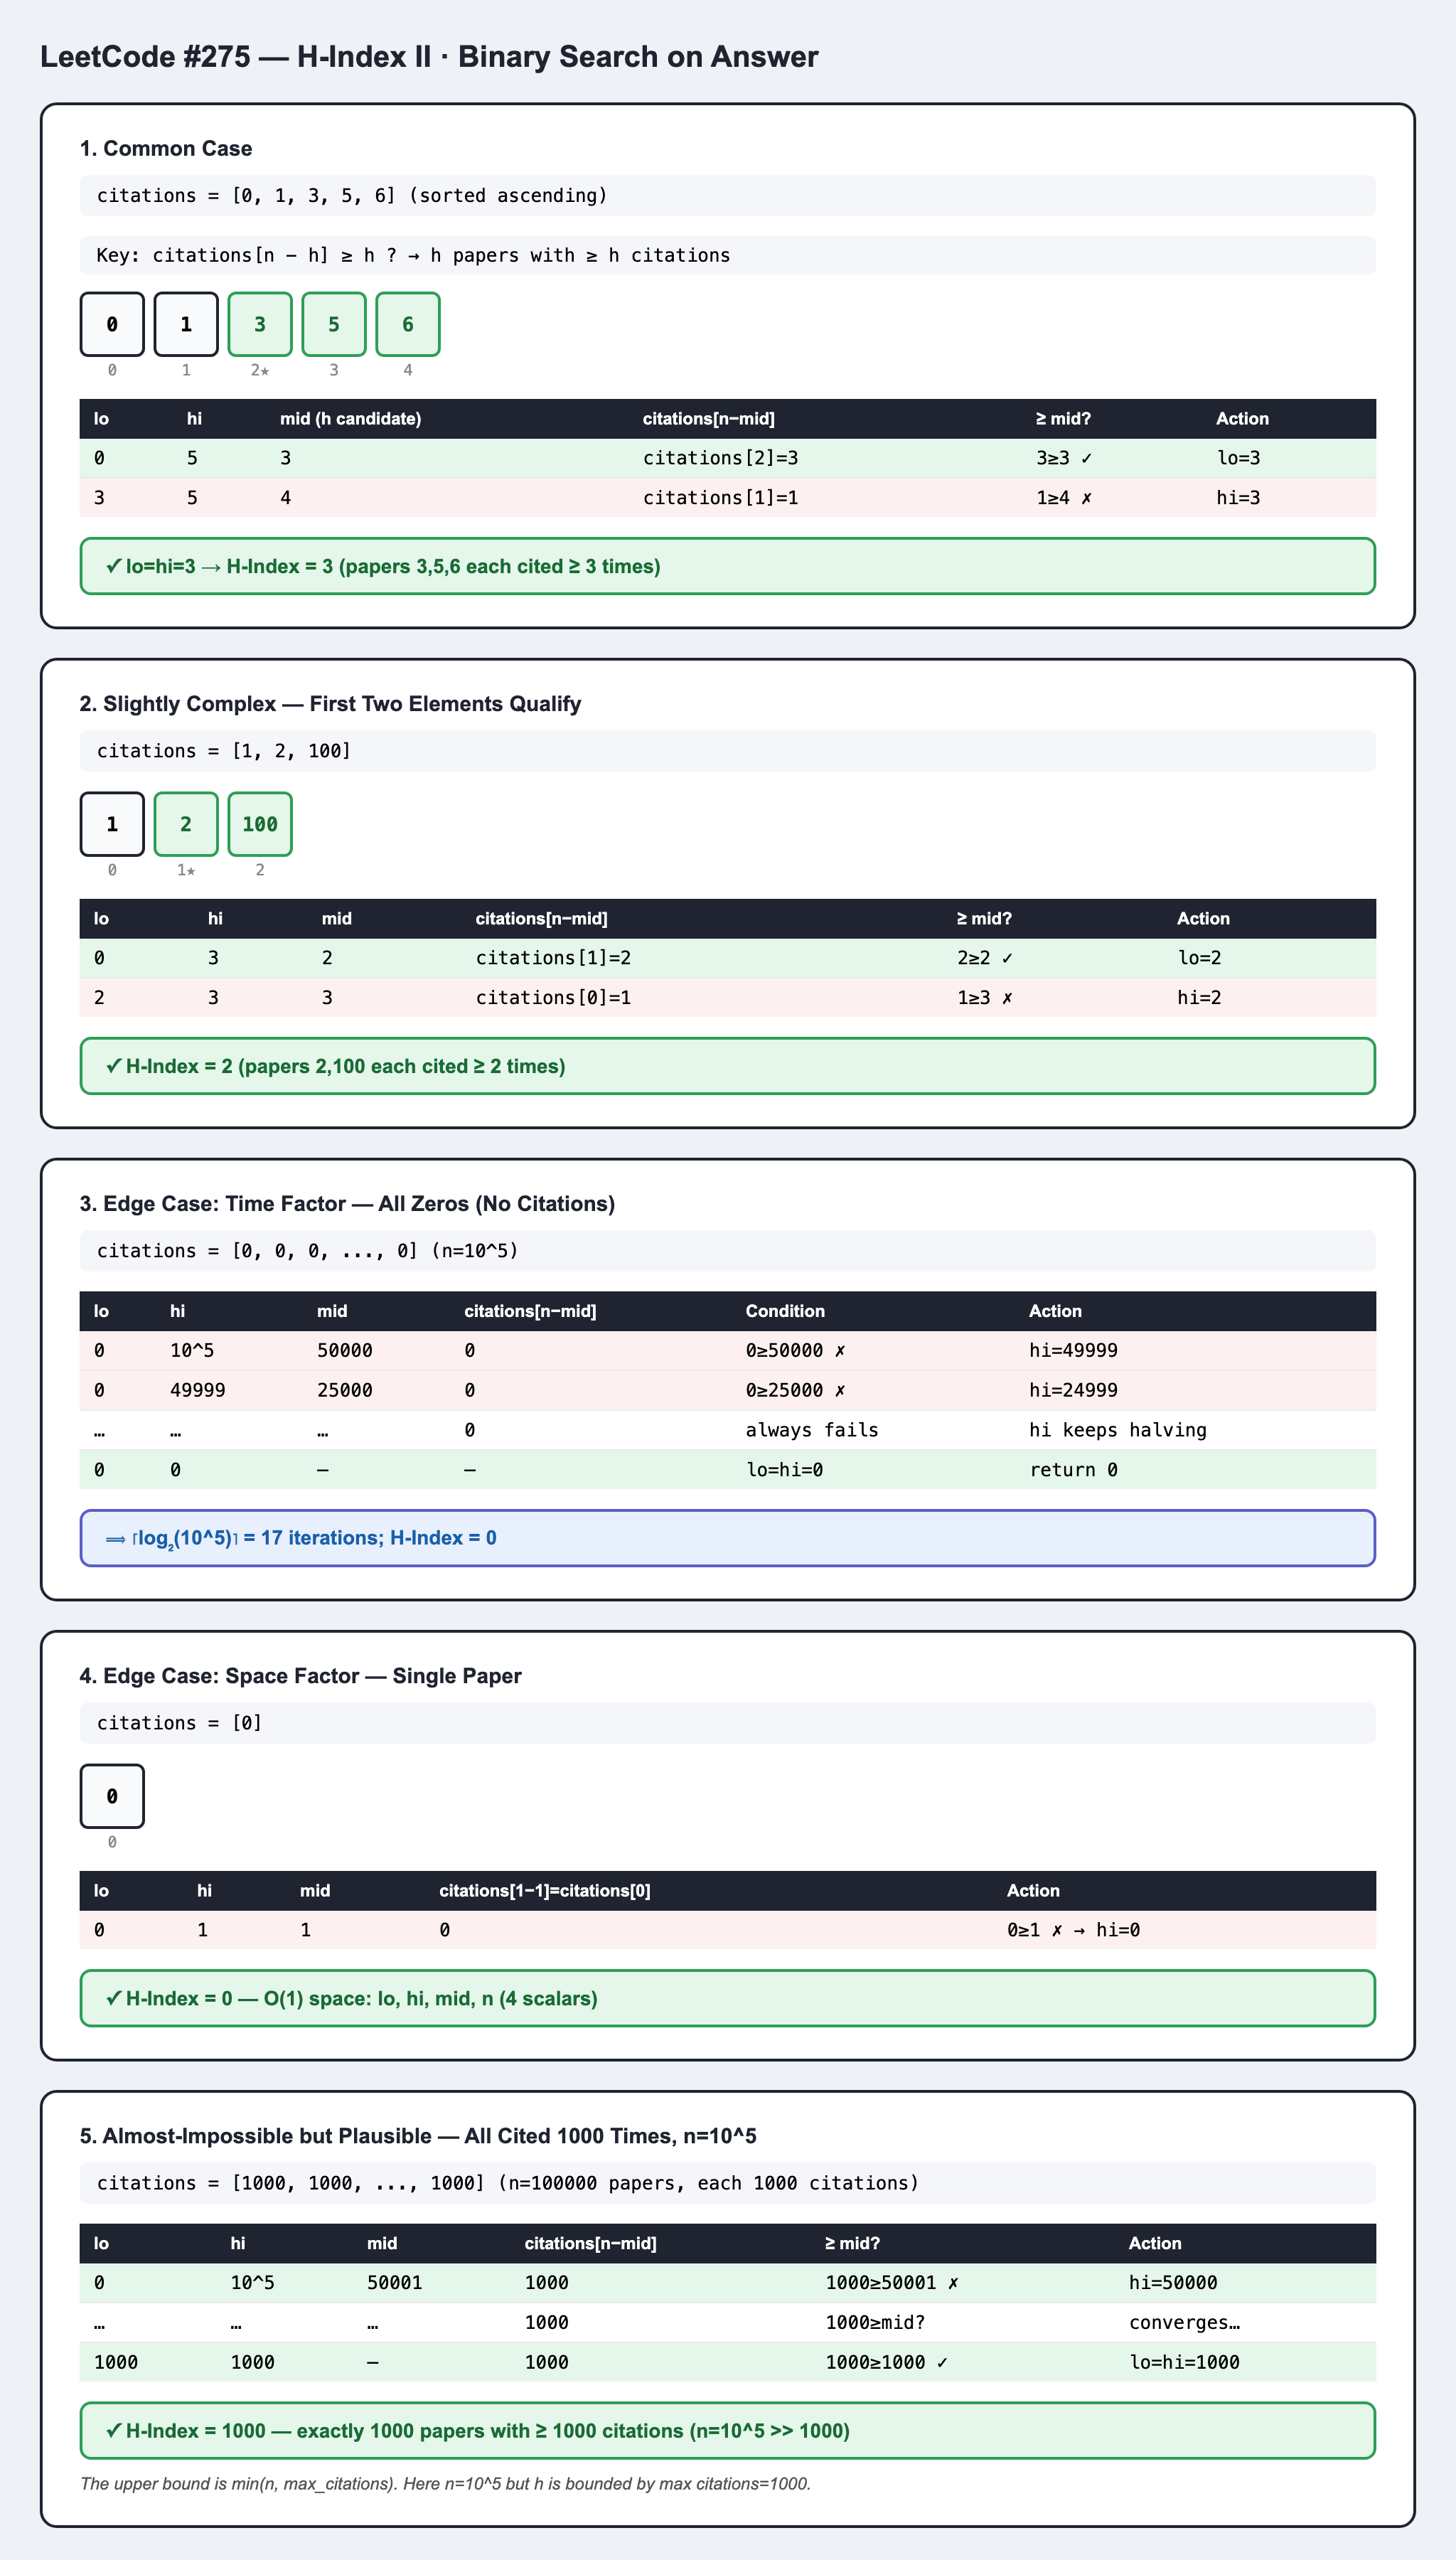